In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

In [48]:
def create_simple_bar_chart(df, x_column, y_column, ylabel=None, width=0.6):
    """
    Simple categorical bar chart with smart ordering and labels.
    Titles are intentionally omitted (y-axis label only).
    """
    df_sorted = df.copy()

    # Ordering rules
    if x_column in ('Traffic', 'Traffic Level'):
        order_map = {'Low': 0, 'Mid': 1, 'High': 2}
        df_sorted['_sort'] = df_sorted[x_column].map(order_map)
        df_sorted = df_sorted.sort_values('_sort').drop(columns=['_sort'])
    elif x_column in ('Number of Modules', 'Modules'):
        order = ['4M', '5M', '6M', '7M']
        df_sorted['_sort'] = df_sorted[x_column].apply(lambda v: order.index(v) if v in order else len(order))
        df_sorted = df_sorted.sort_values('_sort').drop(columns=['_sort'])
    elif x_column == 'Swapping Time':
        df_sorted['_val'] = df_sorted[x_column].astype(str).str.replace('min', '', regex=False).astype(float)
        df_sorted = df_sorted.sort_values('_val').drop(columns=['_val'])
    elif x_column == 'Threshold':
        df_sorted['_val'] = df_sorted[x_column].astype(str).str.replace('Threshold', '', regex=False).astype(float)
        df_sorted = df_sorted.sort_values('_val').drop(columns=['_val'])
    else:
        df_sorted = df_sorted.sort_values(x_column)

    x_values = df_sorted[x_column].values
    y_values = df_sorted[y_column].values
    x_pos = np.arange(len(x_values))

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(x_pos, y_values, width=width, color='#1f77b4', edgecolor='black', linewidth=0.5)

    for bar, val in zip(bars, y_values):
        height = bar.get_height()
        if val < 10:
            label_text = f"{val:.2f}"
        elif val < 100:
            label_text = f"{val:.1f}"
        else:
            label_text = f"{int(val)}"
        ax.text(bar.get_x() + bar.get_width()/2, height, label_text,
                ha='center', va='bottom', fontsize=10, fontweight='normal')

    ax.set_xlabel(x_column, fontweight='bold')
    ax.set_ylabel(ylabel or y_column, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_values)

    y_min, y_max = min(y_values), max(y_values)
    y_range = y_max - y_min
    if y_min > 0 and y_range > 0:
        if y_min > y_range * 0.5:
            y_bottom = max(0, y_min * 0.95)
        else:
            y_bottom = max(0, y_min - y_range * 0.1)
        ax.set_ylim(bottom=y_bottom, top=y_max * 1.05)
    else:
        ax.set_ylim(bottom=0, top=y_max * 1.05)

    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7, color='gray')
    ax.set_axisbelow(True)
    plt.tight_layout()
    return fig, ax

In [49]:
# Load data
base_path = Path.cwd()
if base_path.name == 'viz':
    base_path = base_path.parent

data_dir = base_path / 'sumo_2000_data'

df_traffic = pd.read_csv(data_dir / 'traffic_summary.csv')
df_modules = pd.read_csv(data_dir / 'moduleschange_summary.csv')
df_swapping = pd.read_csv(data_dir / 'swappingtime_summary.csv')
df_threshold = pd.read_csv(data_dir / 'threshold_summary.csv')

display(df_traffic.head())
display(df_modules.head())
display(df_swapping.head())
display(df_threshold.head())

,Traffic Level,Total Travel Time,Total Energy Consumed,Total Distance Covered,Run Time,Total Module Swapped
0,Low,333.19,50.142,237.81,2504.687,2
1,Mid,391.69,45.837,237.81,2880.680,2
2,High,446.05,41.586,237.81,2546.463,2


,Number of Modules,Total Travel Time,Total Energy Consumed,Total Distance Covered,Run Time,Total Module Swapped
0,4,391.13,53.213,249.50,3322.438,2
1,5,383.62,52.364,242.05,3290.292,2
2,6,378.55,50.174,238.43,3386.992,2
3,7,358.44,49.181,228.05,2868.736,2


,Swapping Time,Total Travel Time,Total Energy Consumed,Total Distance Covered,Run Time,Total Module Swapped
0,1,383.78,51.614,242.27,2895.425,2
1,2,385.78,51.614,242.27,3290.292,2
2,3,387.78,51.614,242.27,2837.367,2
3,4,389.78,51.614,242.27,2704.298,2


,Threshold,Total Travel Time,Total Energy Consumed,Total Distance Covered,Run Time,Total Module Swapped
0,5,378.85,54.121,240.28,2815.760,2
1,10,380.81,55.482,242.18,2791.645,2
2,15,384.70,57.608,245.07,2627.752,2
3,20,390.62,60.364,250.05,3290.292,2


## Traffic (2000 nodes)

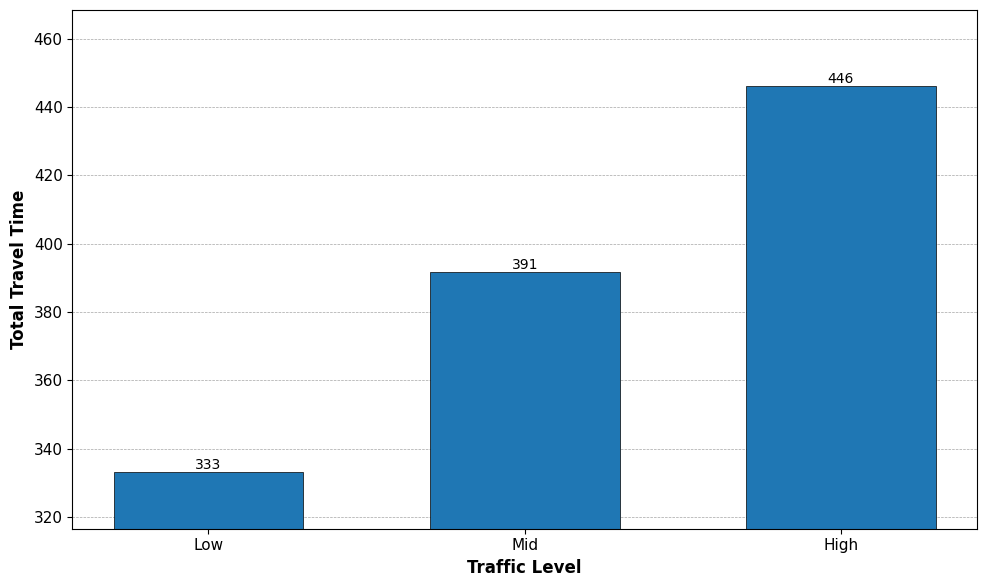

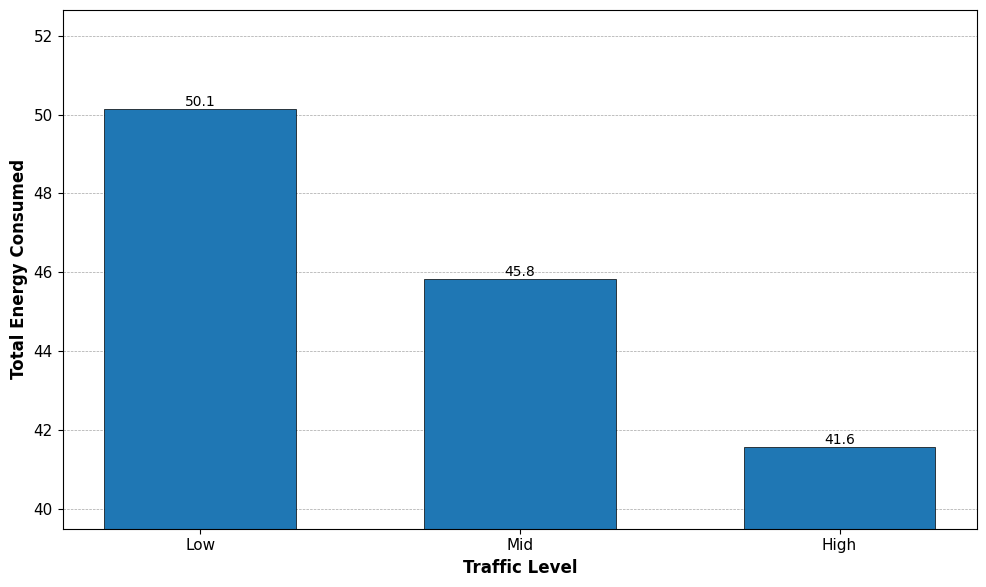

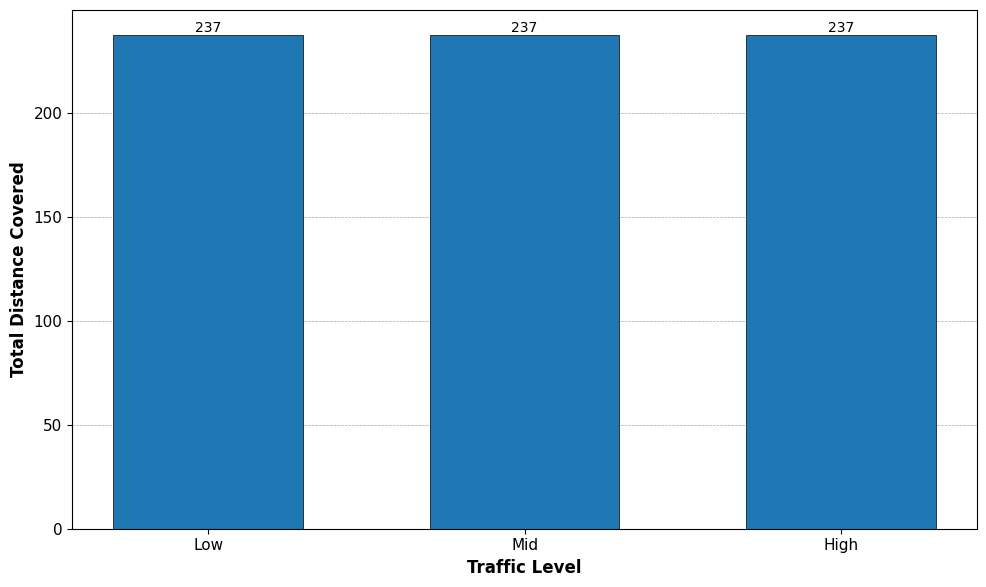

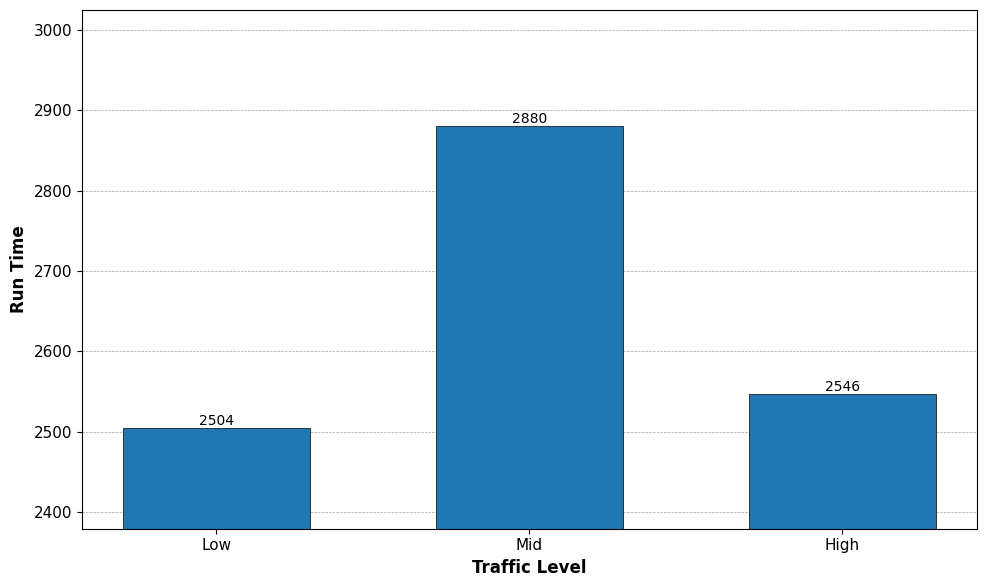

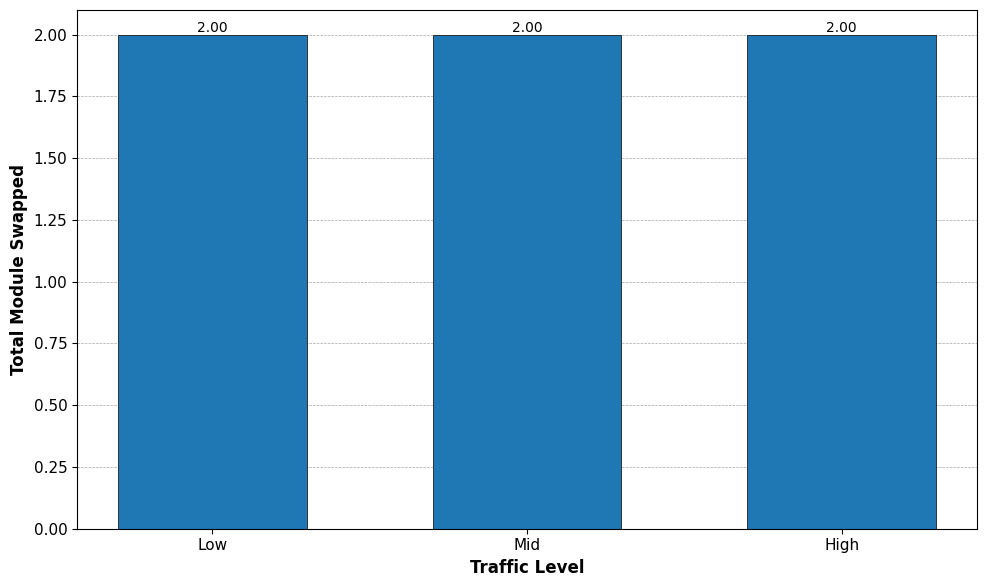

In [50]:
for metric in [
    'Total Travel Time',
    'Total Energy Consumed',
    'Total Distance Covered',
    'Run Time',
    'Total Module Swapped',
]:
    create_simple_bar_chart(df_traffic, 'Traffic Level', metric, ylabel=metric)
    plt.show()

## Module Change (2000 nodes)

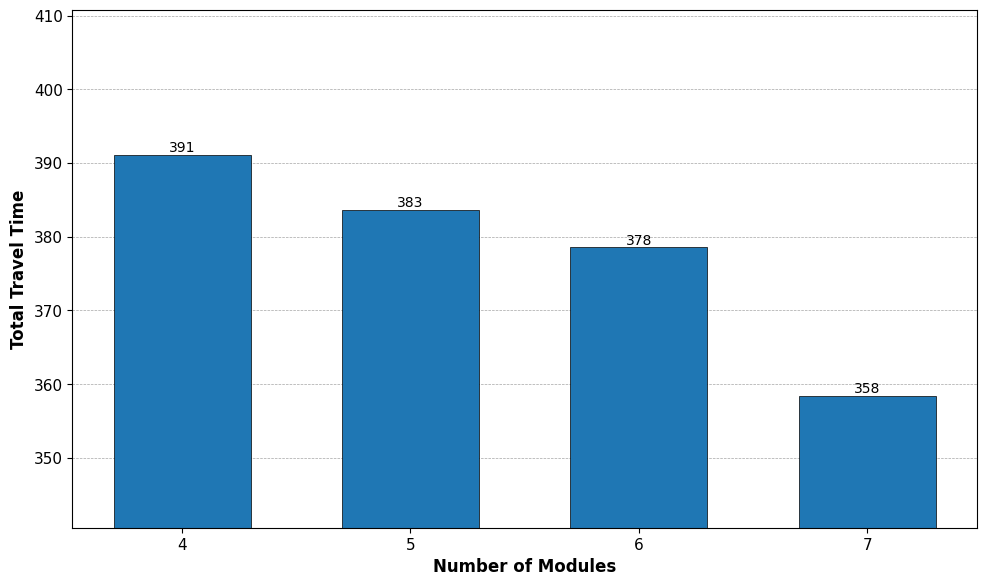

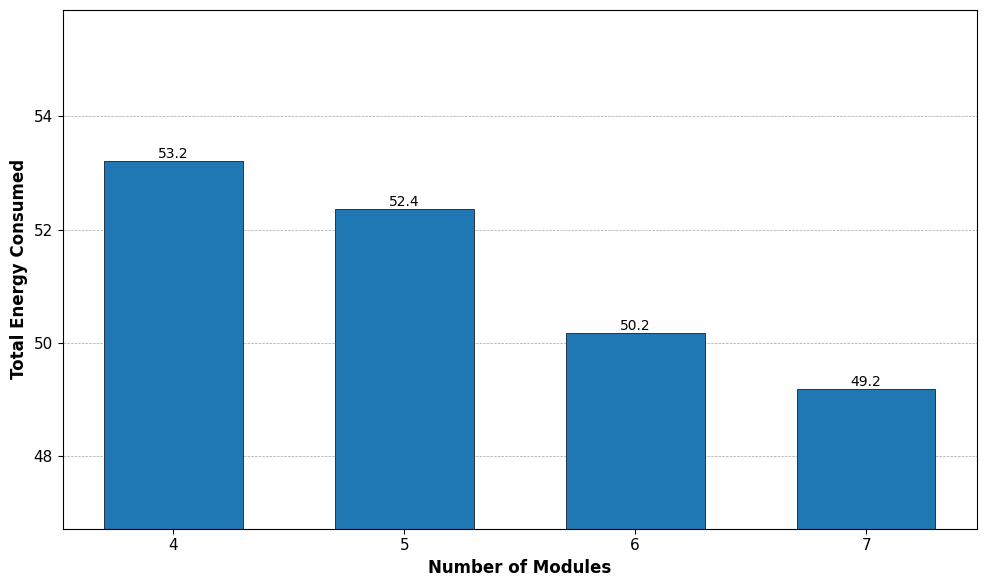

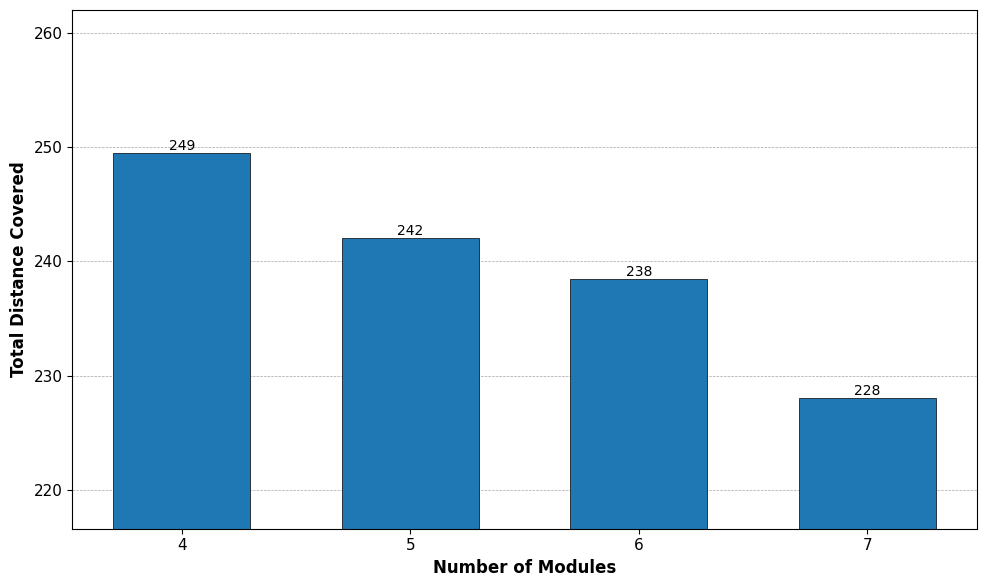

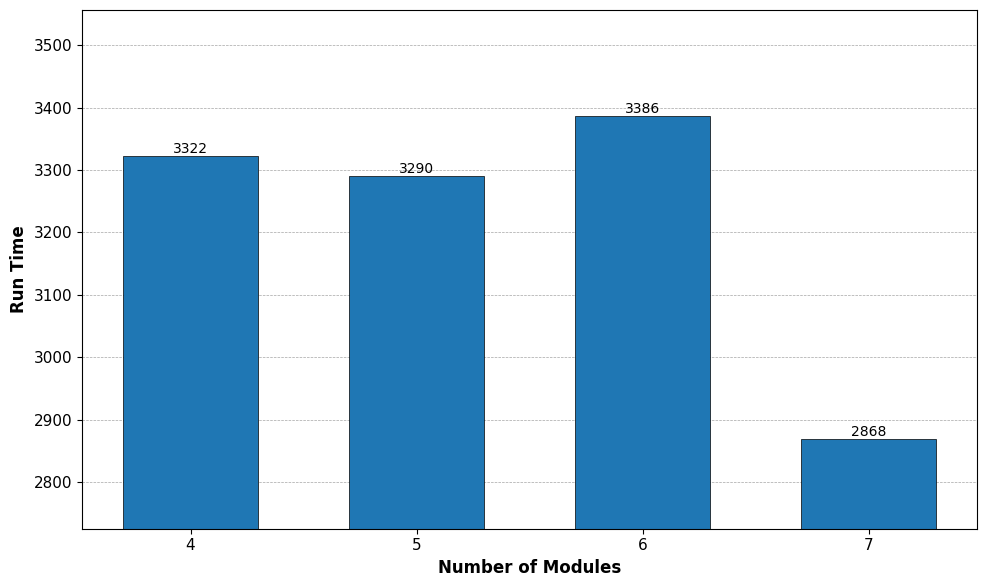

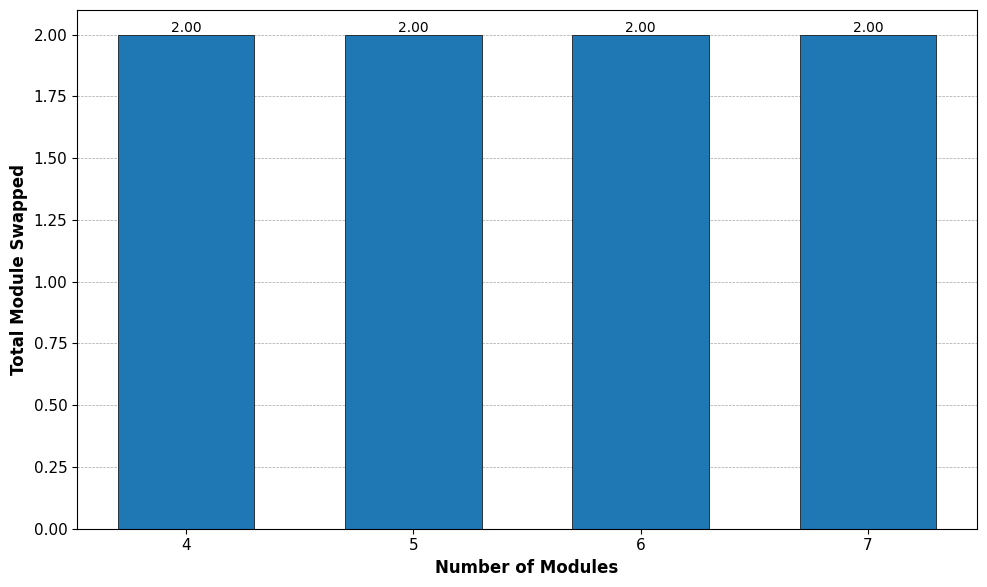

In [51]:
for metric in [
    'Total Travel Time',
    'Total Energy Consumed',
    'Total Distance Covered',
    'Run Time',
    'Total Module Swapped',
]:
    create_simple_bar_chart(df_modules, 'Number of Modules', metric, ylabel=metric)
    plt.show()

## Swapping Time (2000 nodes)

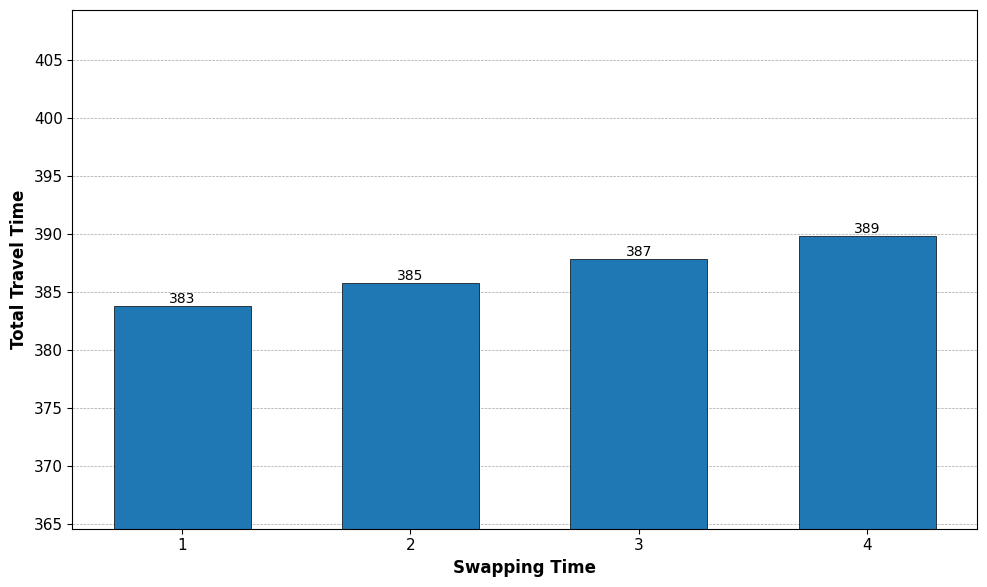

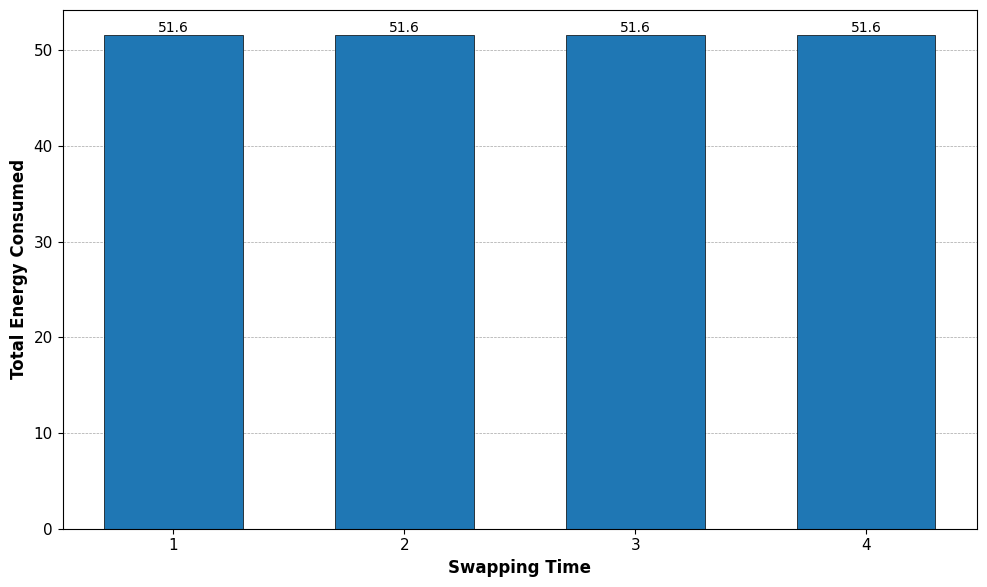

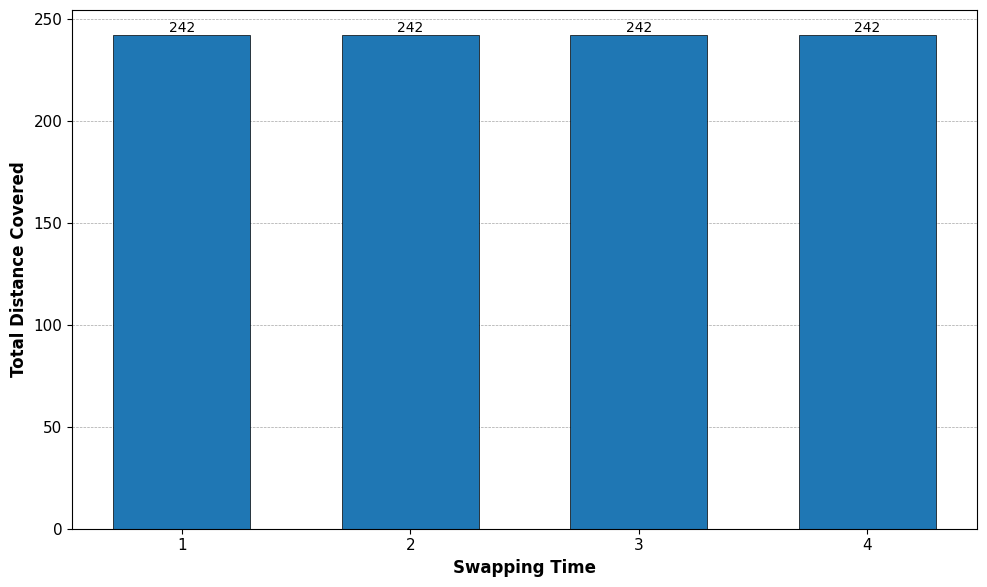

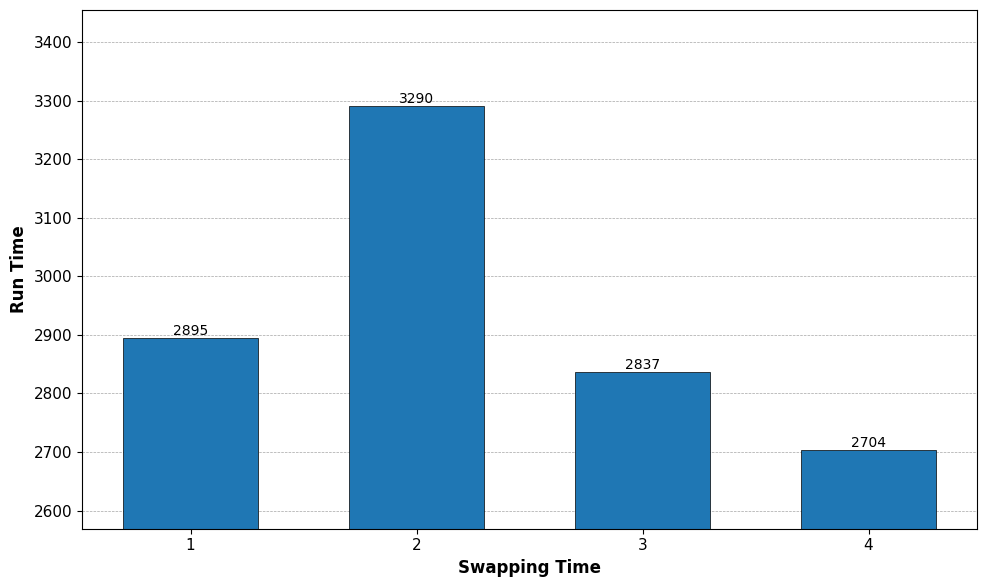

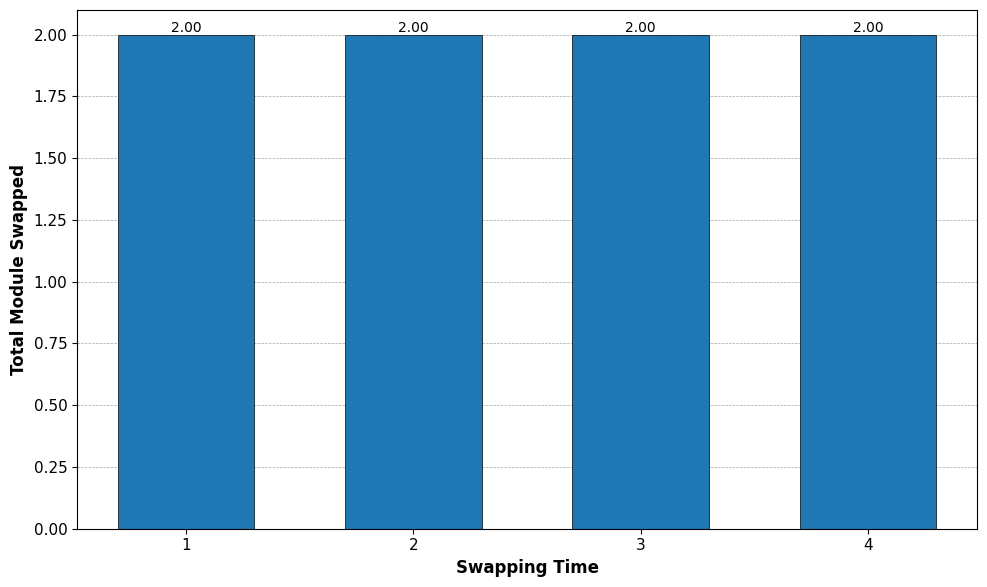

In [52]:
for metric in [
    'Total Travel Time',
    'Total Energy Consumed',
    'Total Distance Covered',
    'Run Time',
    'Total Module Swapped',
]:
    create_simple_bar_chart(df_swapping, 'Swapping Time', metric, ylabel=metric)
    plt.show()

## Threshold (2000 nodes)

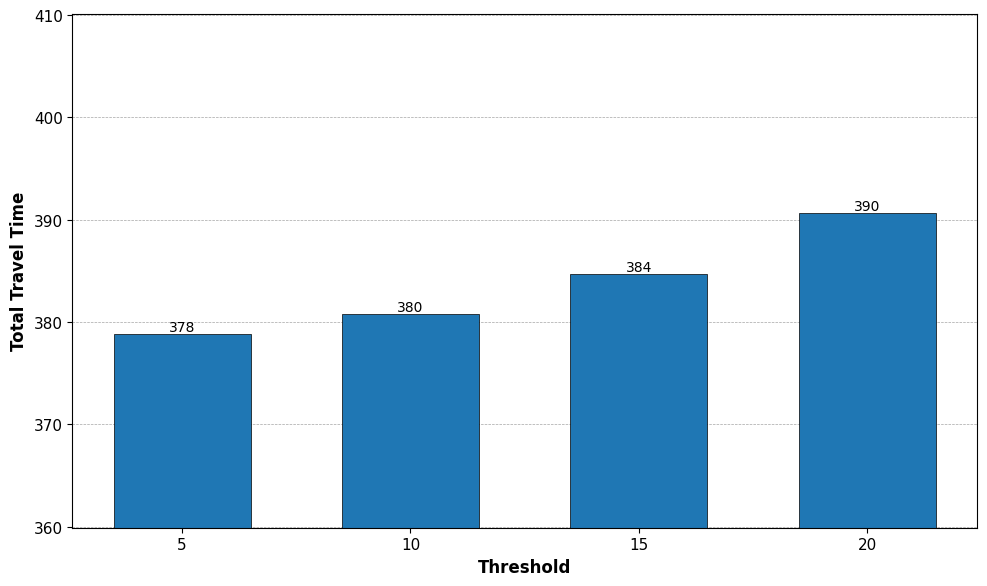

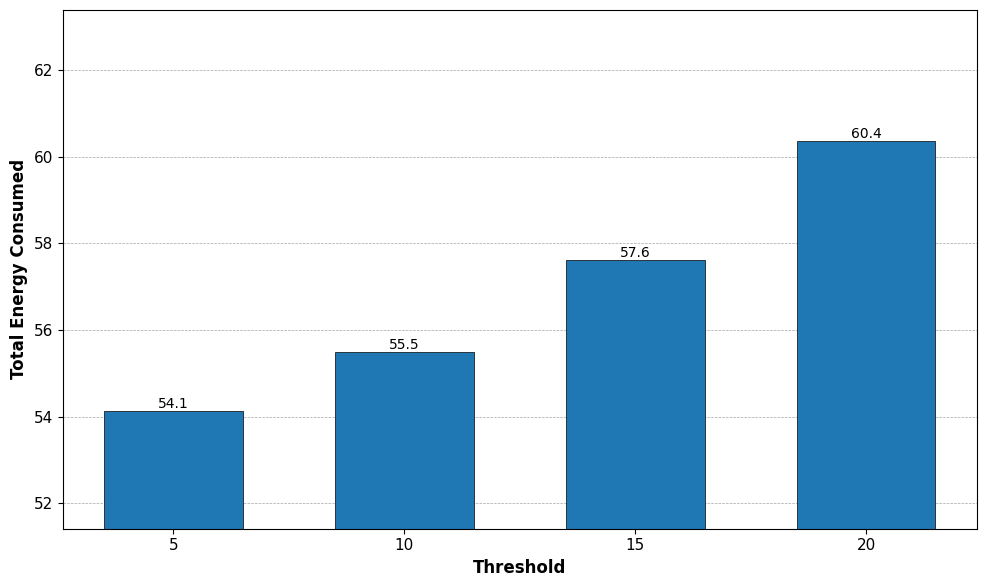

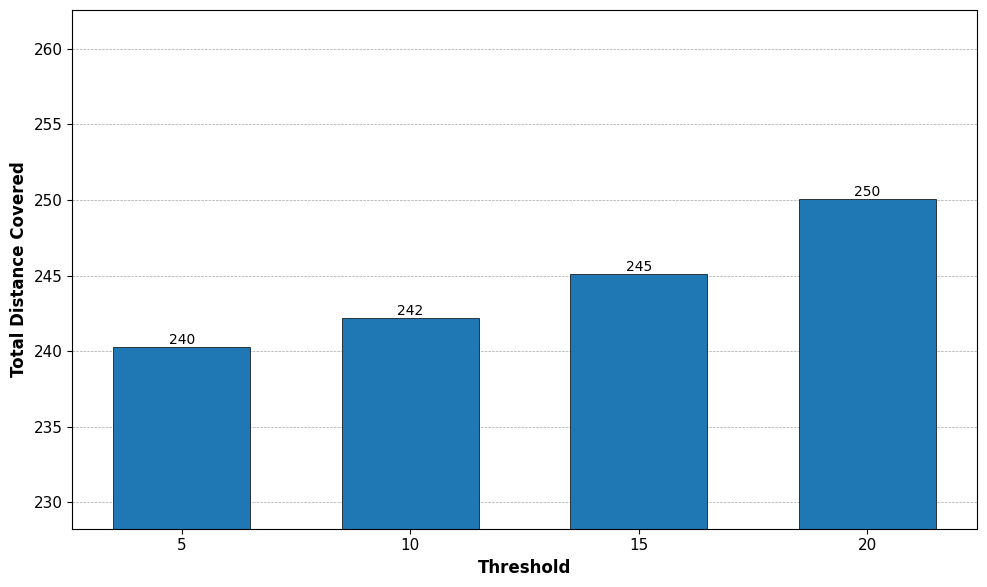

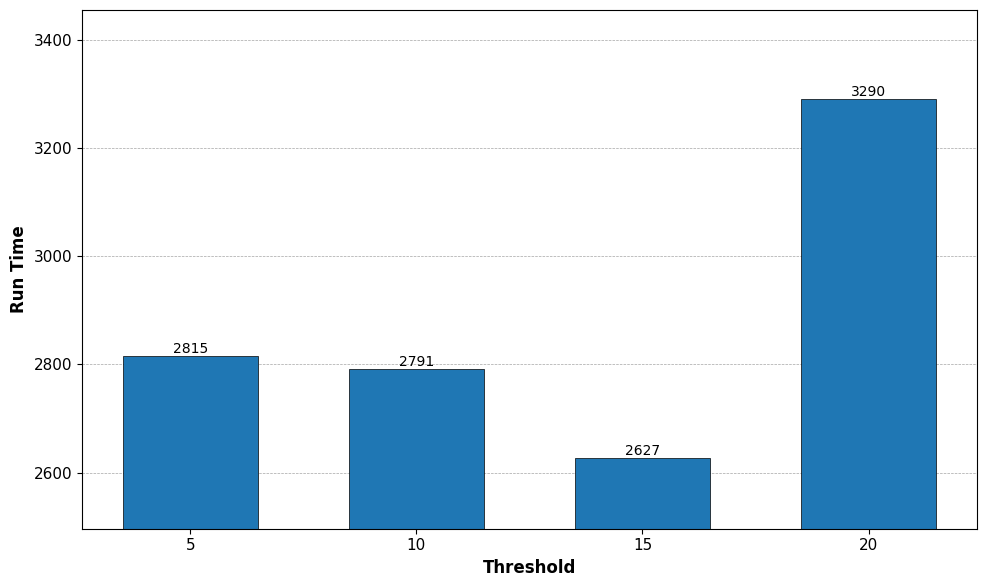

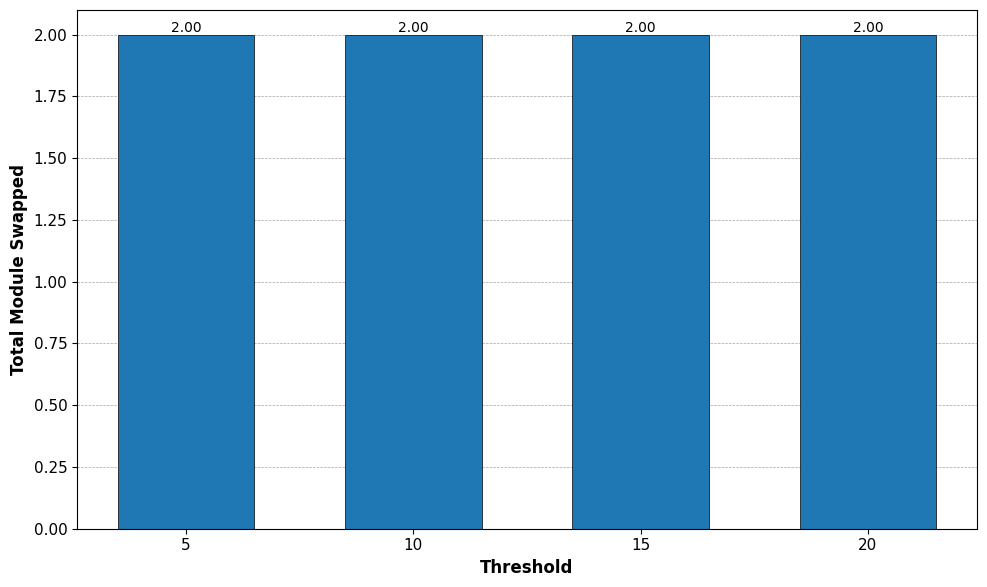

In [53]:
for metric in [
    'Total Travel Time',
    'Total Energy Consumed',
    'Total Distance Covered',
    'Run Time',
    'Total Module Swapped',
]:
    create_simple_bar_chart(df_threshold, 'Threshold', metric, ylabel=metric)
    plt.show()